In [85]:
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
orders = pd.read_csv("orders DA.csv")
order_items = pd.read_csv("order_items DA.csv")
customers = pd.read_csv("customers DA.csv")
products = pd.read_csv("products DA.csv")
payments = pd.read_csv("payments DA.csv")
returns = pd.read_csv("returns DA.csv")
inventory = pd.read_csv("inventory DA.csv")
suppliers = pd.read_csv("suppliers DA.csv")

In [87]:
orders["order_date"] = pd.to_datetime(orders["order_date"], format="%d-%m-%Y")
orders["delivered_date"] = pd.to_datetime(orders["delivered_date"], format="%d-%m-%Y")

customers["registration_date"] = pd.to_datetime(customers["registration_date"], format="%d-%m-%Y")
customers["last_login_date"] = pd.to_datetime(customers["last_login_date"], format="%d-%m-%Y")

payments["payment_date"] = pd.to_datetime(payments["payment_date"], format="%d-%m-%Y")
payments["refund_date"] = pd.to_datetime(payments["refund_date"])

returns["return_date"] = pd.to_datetime(returns["return_date"], format="%d-%m-%Y")
returns["refund_date"] = pd.to_datetime(returns["refund_date"], format="%d-%m-%Y")

products["launch_date"] = pd.to_datetime(products["launch_date"], format="%d-%m-%Y")

inventory["last_restocked_date"] = pd.to_datetime(inventory["last_restocked_date"], format="%d-%m-%Y")

suppliers["created_date"] = pd.to_datetime(suppliers["created_date"], format="%d-%m-%Y")

In [88]:
#1.Monthly order volume — a bar or line chart showing number of orders per month for all 24 months. Highlight the Diwali months (Oct, Nov).

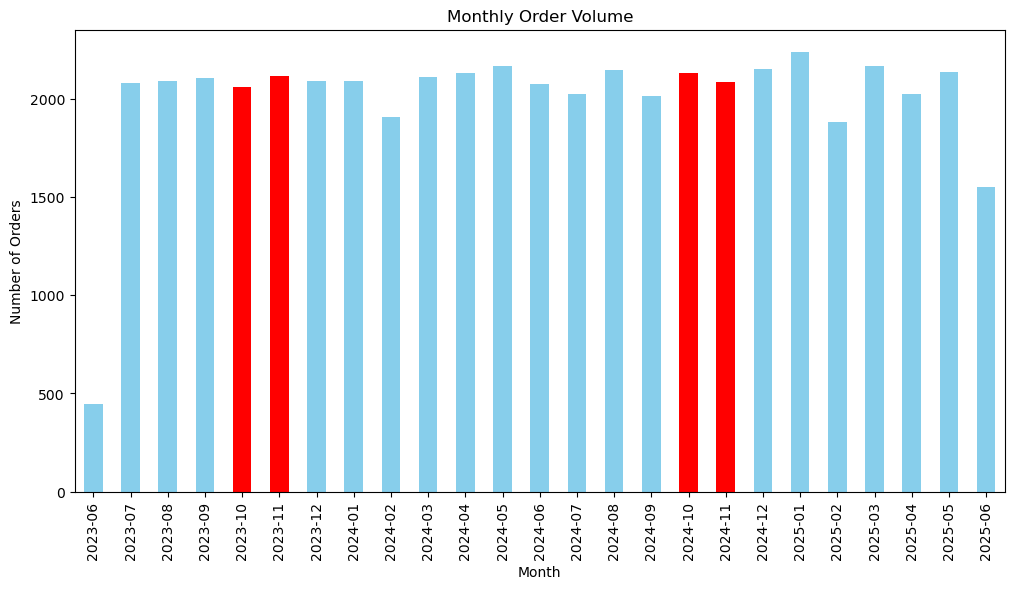

In [89]:
orders["year_month"] = orders["order_date"].dt.to_period("M")
monthly_orders = orders.groupby("year_month")["order_id"].count()

colors = []
for month in monthly_orders.index:
    if month.month in [10, 11]:
        colors.append("red")
    else:
        colors.append("skyblue")

monthly_orders.plot(kind="bar",color=colors,figsize=(12,6))   
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.savefig("Chart1_Monthly_Order_Volume.png", dpi=300)

### Observation

- Monthly order volume remains fairly stable across the 24-month period, with most months recording around 2,000–2,200 orders.
- The highlighted Diwali months (October and November) show order volumes comparable to or slightly higher than the surrounding months, indicating consistent festive-season demand.
- A noticeable decline is observed in June 2025, which may be because the dataset contains only partial data for that month or reflects a temporary drop in orders.

In [90]:
#2.Monthly revenue (GMV) — same as above but using final_amount. Compare year-over-year.

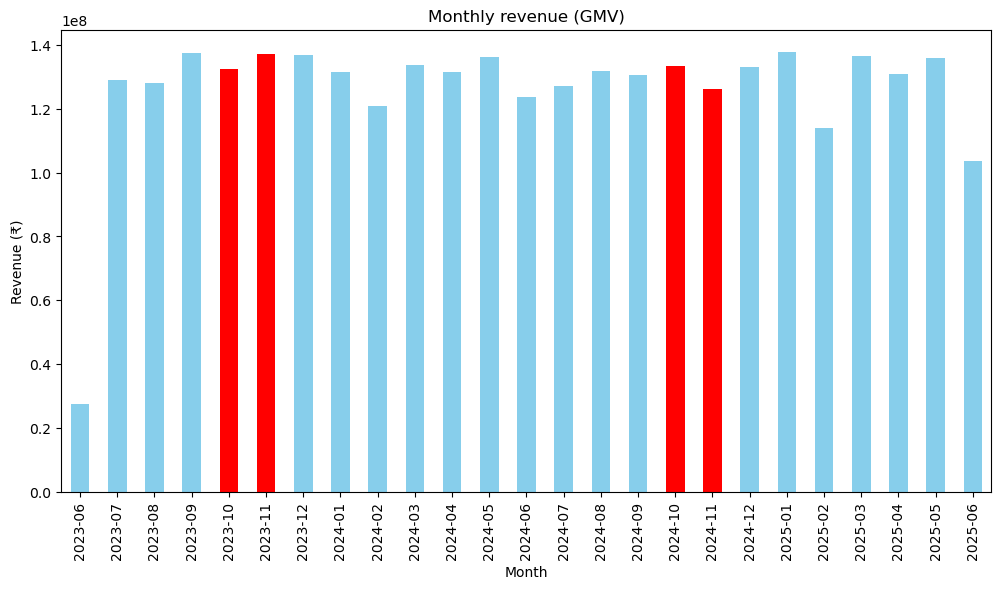

In [91]:
orders["year_month"] = orders["order_date"].dt.to_period("M")
monthly_revenue = orders.groupby("year_month")["final_amount"].sum()

colors = []
for month in monthly_revenue.index:
    if month.month in [10, 11]:
        colors.append("red")
    else:
        colors.append("skyblue")
        
monthly_revenue.plot(kind="bar",color=colors,figsize=(12,6))   
plt.title("Monthly revenue (GMV)")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.savefig("Chart2_Monthly_Revenue (GMV).png", dpi=300)

### Observation

- Monthly GMV remained relatively stable over the 24-month period, with most months generating revenue between **₹1.2–1.4 crore**, indicating consistent business performance.
- The highlighted **Diwali months (October and November)** recorded comparatively higher revenue than many other months, reflecting increased festive-season sales.
- A year-over-year comparison shows slightly stronger revenue in the beginning of **2025** compared to **2024**, while the lower revenue in **June 2025** is likely due to partial monthly data.

In [92]:
#3.Category-wise revenue share — a pie chart or horizontal bar chart. Which category earns the most?

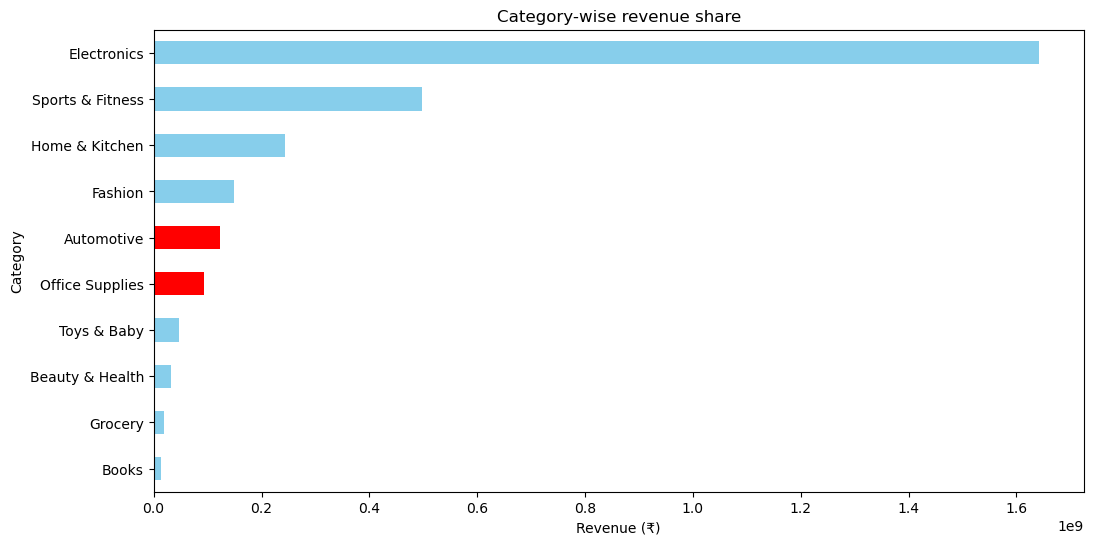

In [93]:
revenue_share = order_items.groupby("category")["total_price"].sum()
revenue_share_sorted = revenue_share.sort_values(ascending=True)
        
revenue_share_sorted.plot(kind="barh",color=colors,figsize=(12,6))   
plt.title("Category-wise revenue share")
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")
plt.savefig("Chart3_Category_Revenue_Share.png", dpi=300)

### Observation

- **Electronics** is the highest revenue-generating category by a significant margin, contributing substantially more revenue than all other categories.
- **Sports & Fitness** ranks second, followed by **Home & Kitchen**, while categories such as **Books**, **Grocery**, and **Beauty & Health** contribute comparatively lower revenue.
- The revenue distribution is highly concentrated, indicating that a few product categories drive the majority of overall sales.

In [94]:
#4.Order status distribution — a donut chart showing % of Delivered, Cancelled, Returned, Shipped, Processing.

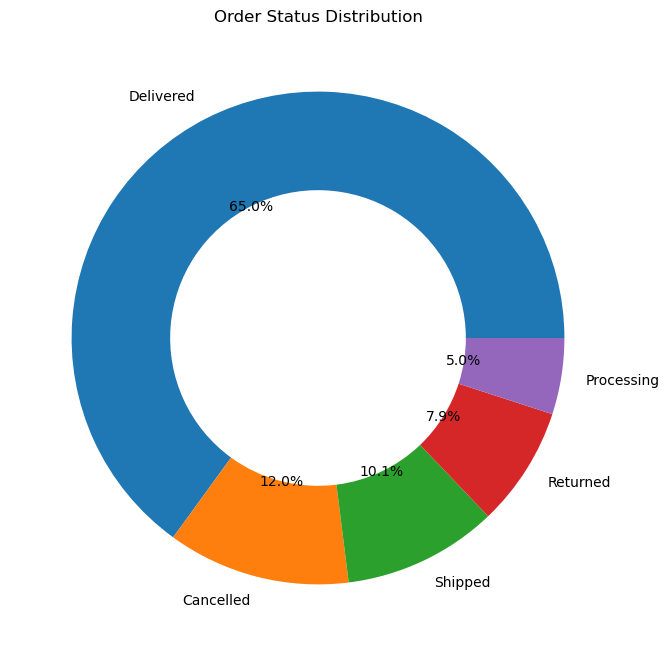

In [95]:
Order_status_dist = orders["status"].value_counts()

Order_status_dist.plot(kind="pie", autopct="%1.1f%%", wedgeprops={"width":0.4}, figsize=(8,8)) 

plt.title("Order Status Distribution")
plt.ylabel("")
plt.savefig("Chart4_Order_Status_Dist.png", dpi=300)

### Observation

- **Delivered** orders account for the majority of all orders (**65.0%**), indicating a strong order fulfillment rate.
- **Cancelled (12.0%)** and **Shipped (10.1%)** are the next most common order statuses, while **Returned (7.9%)** and **Processing (5.0%)** represent a relatively smaller share.
- The high proportion of delivered orders suggests efficient order completion, though the cancellation and return rates provide opportunities to further improve customer satisfaction and operational performance.

In [96]:
#5.Top 10 states by number of orders — a horizontal bar chart.

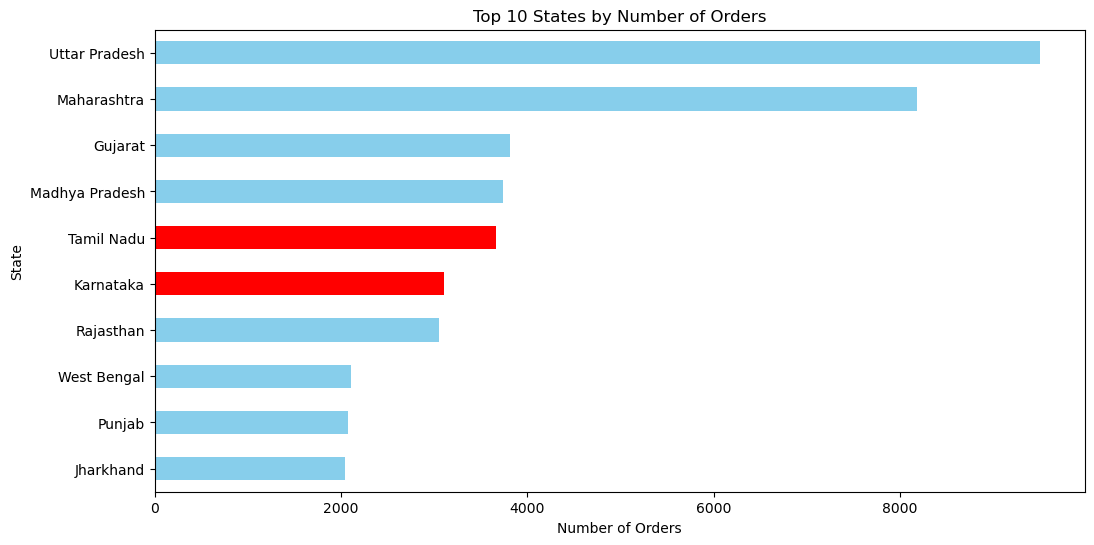

In [97]:
Top10_states = orders["state"].value_counts().head(10)
Top10_states_sorted = Top10_states.sort_values(ascending=True)

Top10_states_sorted.plot(kind="barh", color=colors, figsize=(12,6))

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.savefig("Chart5_Top_10_States_by_Number_of_Orders.png", dpi=300)

### Observation:
- Uttar Pradesh has the highest number of orders, followed by Maharashtra, indicating these are the strongest markets in terms of order volume.
- The remaining states have significantly fewer orders, showing that customer demand is concentrated in a few key states.
- These top-performing states can be prioritized for inventory planning, marketing campaigns, and logistics optimization.

In [98]:
#6.Customer segment distribution — a pie chart. How many Premium vs. Regular vs. Budget customers?

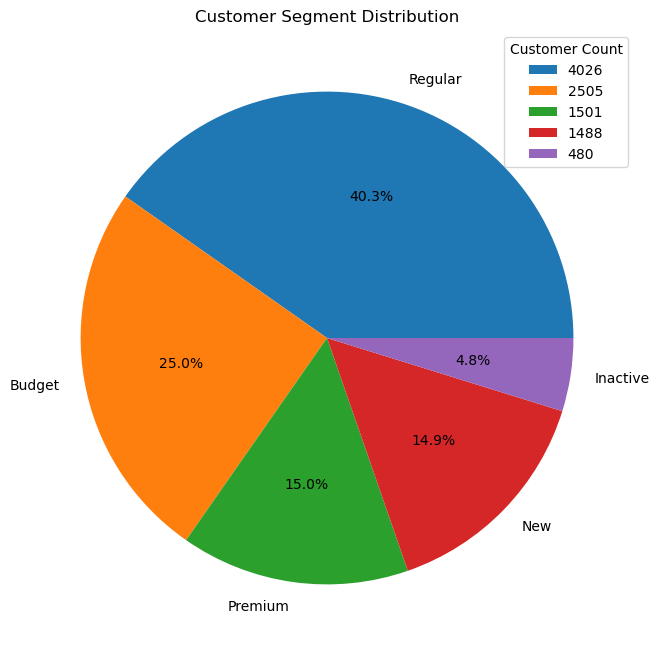

In [99]:
customer_segment_dist = customers["segment"].value_counts()

customer_segment_dist.plot(kind="pie", autopct="%1.1f%%", labels=customer_segment_dist.index, figsize=(8,8)) 
plt.legend(customer_segment_dist.values, title="Customer Count")

plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.savefig("Chart6_Customer_Segment_Dist.png", dpi=300)

### Observation:
- Regular customers are the largest customer segment with **4,026 customers (40.3%)**, followed by **Budget (2,505; 25.0%)** and **Premium (1,501; 15.0%)**.
- New customers account for **1,488 (14.9%)**, while **Inactive customers (480; 4.8%)** represent the smallest segment.
- The business has a strong base of Regular customers, while targeted retention and loyalty programs can help convert New and Budget customers into Premium customers.

In [100]:
#7.Payment method usage — a bar chart showing which methods are most popular.

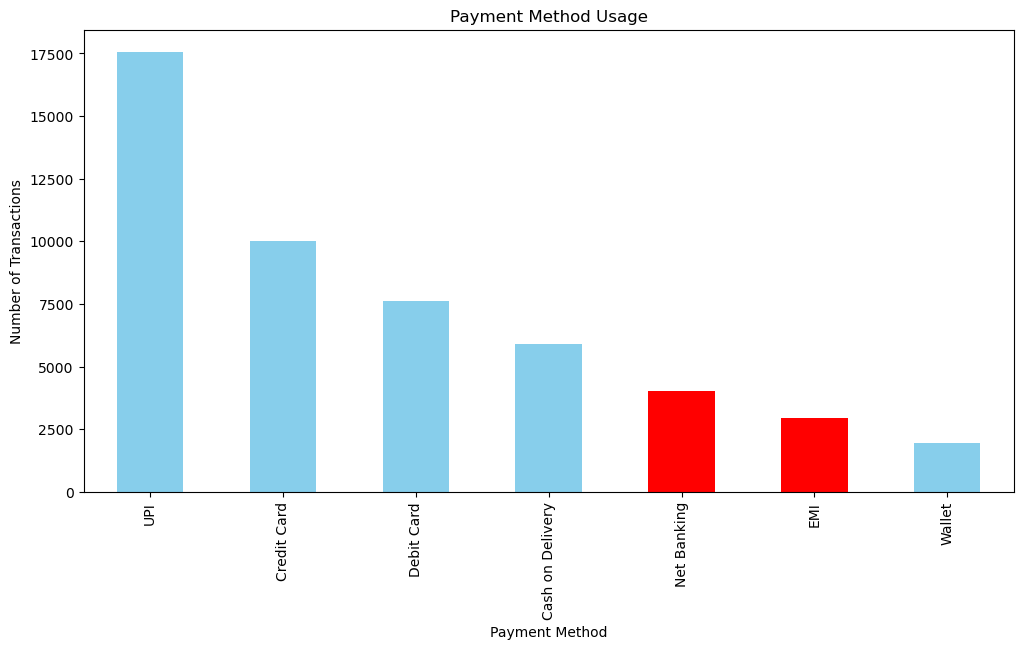

In [101]:
payment_method = payments.groupby("payment_method")["payment_id"].count()
payment_method_sorted = payment_method.sort_values(ascending=False)

payment_method_sorted.plot(kind="bar",color=colors,figsize=(12,6))   
plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.savefig("Chart7_Payment_Method_Usage.png", dpi=300)

### Observation:
- UPI is the most preferred payment method, followed by Credit Card and Debit Card, indicating a strong preference for digital payments.
- Delivery-based payments and online banking are used less frequently, while Wallet has the lowest adoption among customers.
- The business can continue promoting digital payment options to improve customer convenience and transaction efficiency.

In [102]:
#8.Age distribution of customers — a histogram. What age group shops most?

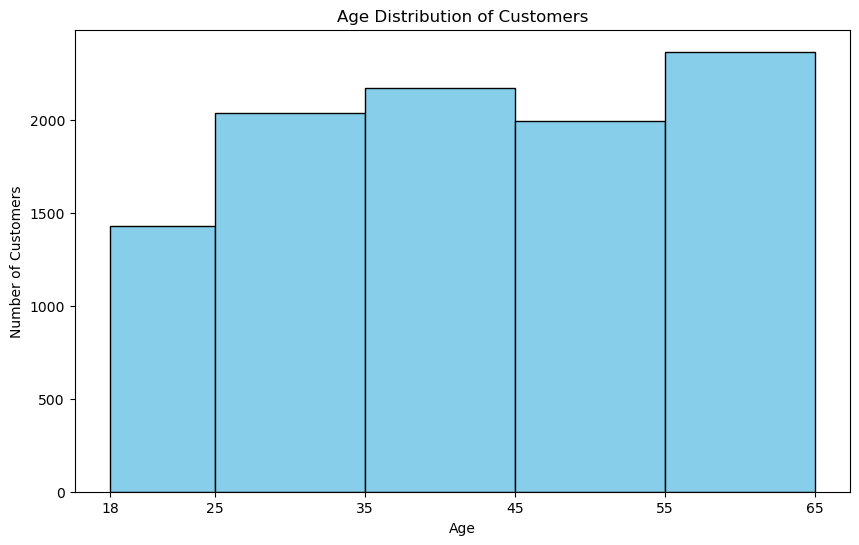

In [103]:
customers["age"].plot(kind="hist", bins=[18,25,35,45,55,65], figsize=(10,6), color="skyblue", edgecolor="black")

plt.xticks([18,25,35,45,55,65])
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("Chart8_Age_Distribution_of_Customers.png", dpi=300)

### Observation:
- The **55–65 years** age group has the highest customer frequency in the histogram, indicating that this age group shops the most in the dataset.
- Customers aged **18–25 years** represent the smallest age group, showing comparatively lower shopping activity.
- Most customers belong to the **25–65 years** age range, suggesting that middle-aged and older customers contribute significantly to the business.

In [104]:
#9.Return reasons — a bar chart of the most common return reasons from returns.csv.

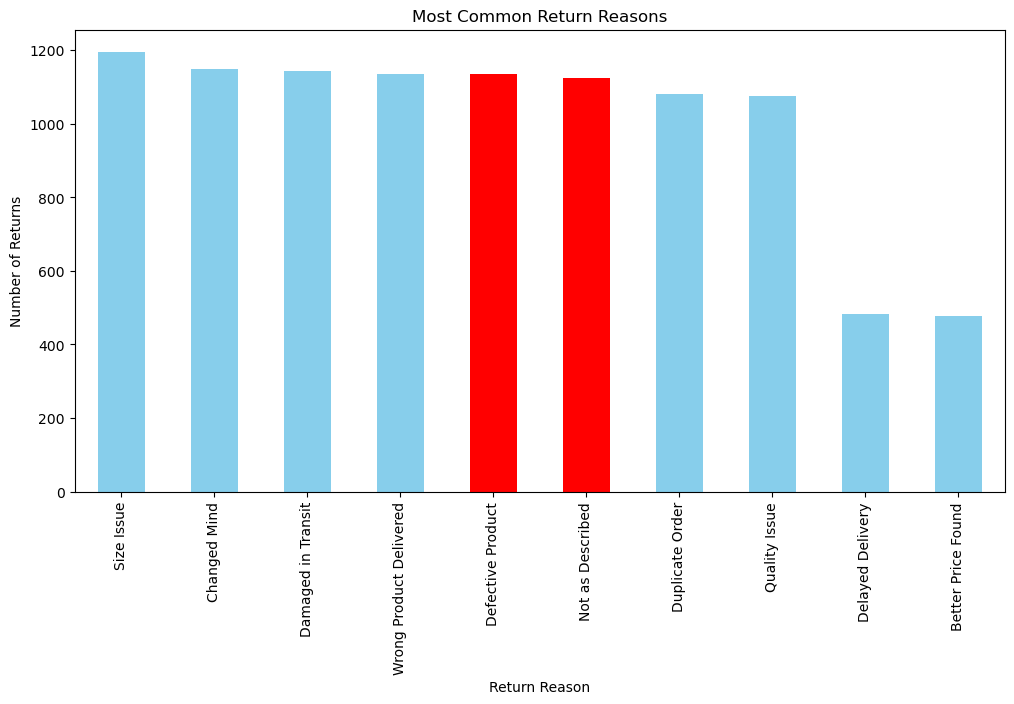

In [105]:
Return_reasons = returns["reason"].value_counts()

Return_reasons.plot(kind="bar",color=colors, figsize=(12,6)) 

plt.title("Most Common Return Reasons")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")
plt.savefig("Chart9_Return_reasons.png", dpi=300)

### Observation:
- **Size Issue** is the most common return reason, followed closely by **Changed Mind**, **Damaged in Transit**, **Wrong Product Delivered**, **Defective Product**, and **Not as Described**.
- **Delayed Delivery** and **Better Price Found** are the least common reasons for product returns.
- Most returns are driven by product-related issues and customer expectations rather than delivery delays or pricing concerns.

In [106]:
#10.Average Order Value (AOV) by segment — a bar chart. Do Premium customers spend more per order?

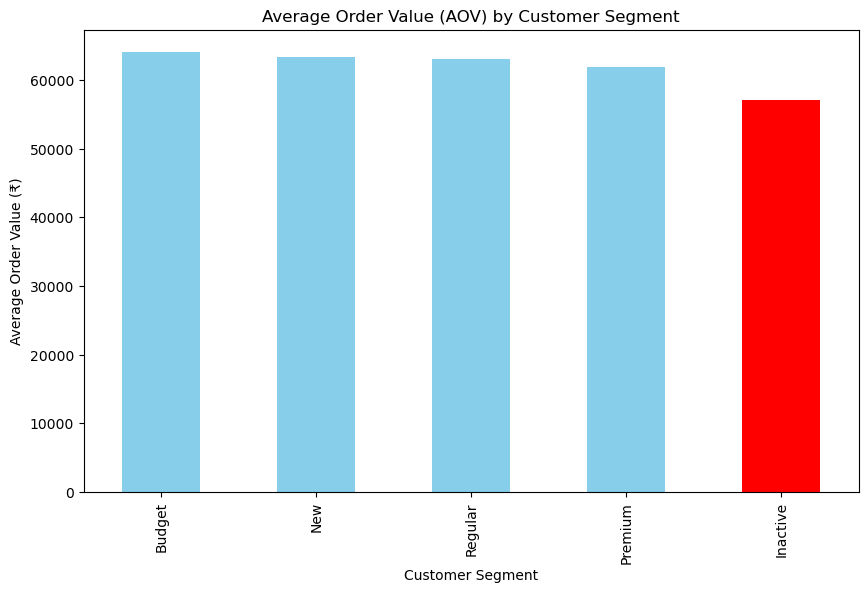

In [107]:
orders_customers = pd.merge(orders, customers, on="customer_id")

AOV_segment = orders_customers.groupby("segment")["final_amount"].mean()
AOV_segment_sorted = AOV_segment.sort_values(ascending=False)

AOV_segment_sorted.plot(kind="bar", color=colors, figsize=(10,6))

plt.title("Average Order Value (AOV) by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")
plt.savefig("Chart10_AOV_by_Segment.png", dpi=300)

### Observation:
- **Budget** customers have the highest Average Order Value (AOV), followed closely by **New** customers.
- **Premium** customers do **not** have the highest AOV in this dataset, as their average order value is slightly lower than Budget, New, and Regular customers.
- **Inactive** customers have the lowest AOV, indicating they spend the least per order on average.